In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
import os
import pandas as pd
import numpy as np

In [18]:
# Load TSV file
rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_Geo.tsv", sep="\t")

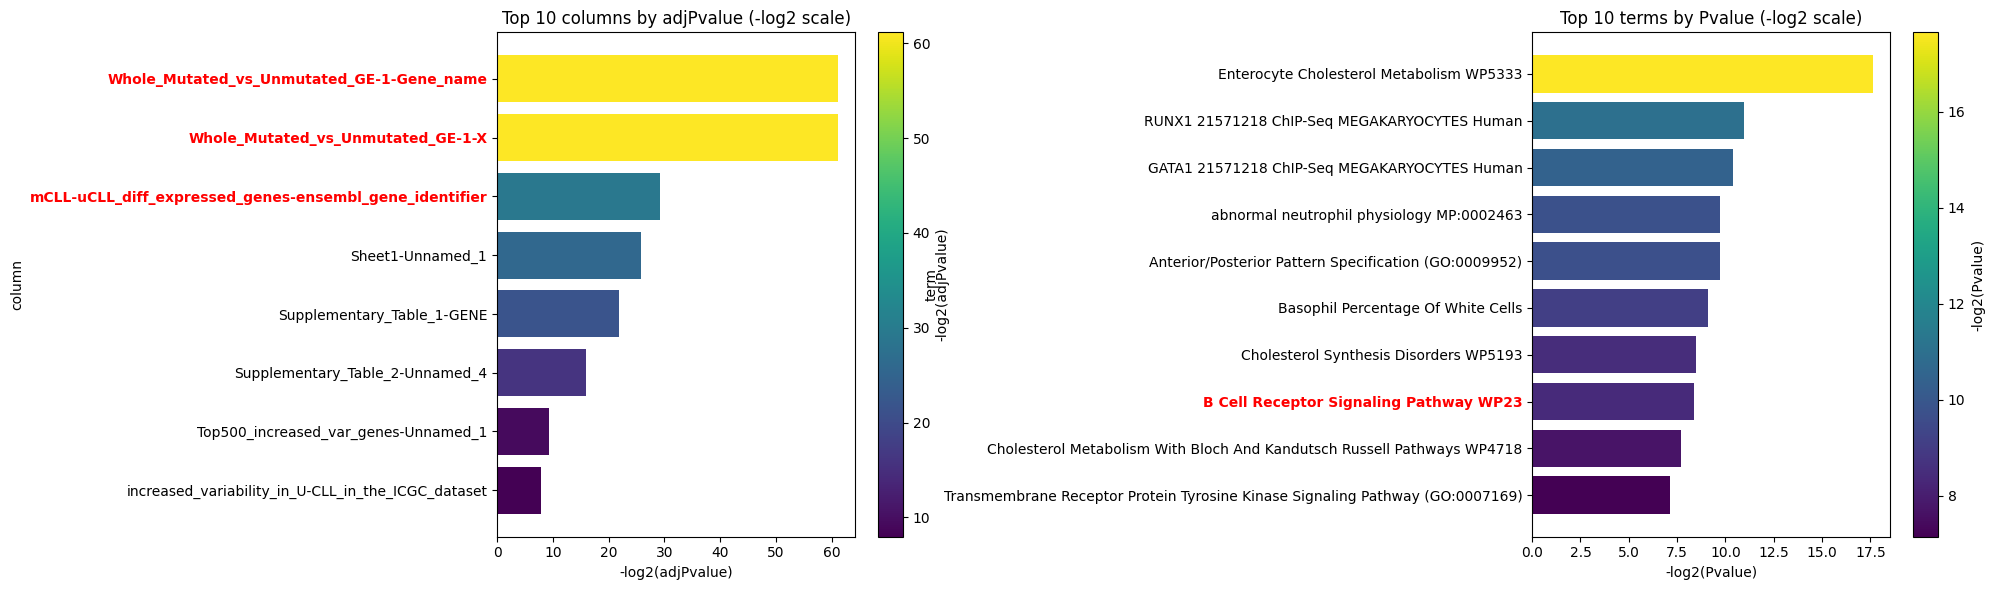

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Prepare the first dataset: rumma_gene ---
rumma_gene["-log2(adjPvalue)"] = -np.log2(rumma_gene["adjPvalue"])

# Replace long column names with shorter versions
long_name = "Top500_increased_var_genes-Column_ICGC_Top_500_genes_with_increased_variability_in_U-CLL_in_the_ICGC_dataset_total_number_of_genes_analyzed_20_474"
short_name = "Increased_variability_in_U-CLL_in_the_ICGC_dataset"
rumma_gene["column"] = rumma_gene["column"].replace(long_name, short_name)

df_top5 = rumma_gene.sort_values("-log2(adjPvalue)", ascending=False).head(10)
df_top5 = df_top5.sort_values("-log2(adjPvalue)", ascending=True)
norm1 = mcolors.Normalize(vmin=df_top5["-log2(adjPvalue)"].min(),
                          vmax=df_top5["-log2(adjPvalue)"].max())
cmap1 = cm.viridis
highlight_cols = [
    "Whole_Mutated_vs_Unmutated_GE-1-Gene_name",
    "Whole_Mutated_vs_Unmutated_GE-1-X",
    "mCLL-uCLL_diff_expressed_genes-ensembl_gene_identifier",
    short_name  # highlight the renamed column too
]

# --- Prepare the second dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])
df_top10 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top10 = df_top10.sort_values("-log2(Pvalue)", ascending=True)
norm2 = mcolors.Normalize(vmin=df_top10["-log2(Pvalue)"].min(),
                          vmax=df_top10["-log2(Pvalue)"].max())
cmap2 = cm.viridis
highlight_term = "B Cell Receptor Signaling Pathway WP23"

# --- Create 1x2 figure ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # 1 row, 2 columns

# --- Left panel: rumma_gene ---
ax = axes[0]
bars1 = ax.barh(
    df_top5["column"],
    df_top5["-log2(adjPvalue)"],
    color=cmap1(norm1(df_top5["-log2(adjPvalue)"]))
)
# Highlight y-axis labels
for label in ax.get_yticklabels():
    if label.get_text() in highlight_cols:
        label.set_color("red")
        label.set_fontweight("bold")
sm1 = cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm1.set_array([])
fig.colorbar(sm1, ax=ax, label="-log2(adjPvalue)")
ax.set_xlabel("-log2(adjPvalue)")
ax.set_ylabel("column")
ax.set_title("Top 10 columns by adjPvalue (-log2 scale)")

# --- Right panel: rumma_geo ---
ax = axes[1]
bars2 = ax.barh(
    df_top10["term"],
    df_top10["-log2(Pvalue)"],
    color=cmap2(norm2(df_top10["-log2(Pvalue)"]))
)
# Highlight y-axis label
for label in ax.get_yticklabels():
    if label.get_text() == highlight_term:
        label.set_color("red")
        label.set_fontweight("bold")
sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
fig.colorbar(sm2, ax=ax, label="-log2(Pvalue)")
ax.set_xlabel("-log2(Pvalue)")
ax.set_ylabel("term")
ax.set_title("Top 10 terms by Pvalue (-log2 scale)")

plt.tight_layout()
fig.savefig("../../figures/Rumma_top_panels_plot.png", dpi=300, bbox_inches="tight")
plt.show()
